# Plant Pathology ResNet-50 — Drive Predictor

This notebook performs prediction only. It does **not** train the model.

It mounts Google Drive and automatically loads:


Run each cell in order and upload one or more leaf photographs.

## 1. Setup

In [ ]:
from google.colab import files
from pathlib import Path

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Load the trained model from Google Drive

Authorize the Google account that contains the `plant_project` folder. The checkpoint is loaded automatically; no model-file upload is required.

In [ ]:

file_id = "1W_cQks5WhGswmqRrsaSWoVQB8nD6pYhj"
url = f"https://drive.google.com/uc?id={file_id}"

output_file = "plant_pathology_resnet50_complete.pt"
checkpoint_path = Path(output_file)

if not checkpoint_path.exists():
    print("Downloading model from Google Drive...")

    downloaded_file = gdown.download(
        url,
        output_file,
        quiet=False,
    )

    if downloaded_file is None:
        raise RuntimeError(
            "Model download failed. Make sure the Google Drive "
            "file is accessible through the link."
        )


if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint was not found: {checkpoint_path}"
    )
try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )



required_keys = {
    "model_state_dict",
    "classes",
    "thresholds",
}

missing_keys = required_keys.difference(checkpoint)

if missing_keys:
    raise ValueError(
        "The file is not a complete inference checkpoint. "
        f"Missing keys: {sorted(missing_keys)}"
    )


architecture = checkpoint.get(
    "architecture",
    "resnet50",
)

if architecture != "resnet50":
    raise ValueError(
        "This notebook expects ResNet-50, "
        f"but the checkpoint contains: {architecture}"
    )

classes = list(checkpoint["classes"])

thresholds = np.asarray(
    checkpoint["thresholds"],
    dtype=np.float32,
)

model = models.resnet50(weights=None)

model.fc = nn.Sequential(
    nn.Dropout(
        checkpoint.get("dropout", 0.35)
    ),
    nn.Linear(
        model.fc.in_features,
        len(classes),
    ),
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

config = checkpoint.get("preprocessing", {})

resize_size = config.get("resize", 256)

crop_size = config.get(
    "center_crop",
    checkpoint.get("image_size", 224),
)

normalization_mean = config.get(
    "mean",
    [0.485, 0.456, 0.406],
)

normalization_std = config.get(
    "std",
    [0.229, 0.224, 0.225],
)


predict_transform = transforms.Compose([
    transforms.Resize(resize_size),

    transforms.CenterCrop(crop_size),

    transforms.ToTensor(),

    transforms.Normalize(
        normalization_mean,
        normalization_std,
    ),
])


print("\nModel loaded successfully.")
print("Architecture:", architecture)
print("Classes:", classes)
print("Thresholds:", thresholds)
print("Image size:", crop_size)
print("No training was performed.")


Model loaded successfully.
Architecture: resnet50
Classes: ['complex', 'frog_eye_leaf_spot', 'healthy', 'powdery_mildew', 'rust', 'scab']
Thresholds: [0.77 0.57 0.43 0.69 0.73 0.72]
Image size: 224
No training was performed.


In [ ]:
def show_gradcam(
    image_path,
    class_name=None,
    target_layer=None,
    overlay_alpha=0.45,
):

    image_path = Path(image_path)

    try:
        with Image.open(image_path) as opened_image:
            original_image = opened_image.convert("RGB")

    except (UnidentifiedImageError, OSError):
        print(
            f"Grad-CAM skipped: "
            f"{image_path.name} is not a readable image."
        )
        return None
    tensor = predict_transform(original_image)
    tensor = tensor.unsqueeze(0).to(device)
    display_tensor = (
        tensor[0]
        .detach()
        .cpu()
        .clone()
    )

    mean_tensor = torch.tensor(
        normalization_mean,
        dtype=display_tensor.dtype,
    ).view(3, 1, 1)

    std_tensor = torch.tensor(
        normalization_std,
        dtype=display_tensor.dtype,
    ).view(3, 1, 1)

    display_tensor = (
        display_tensor * std_tensor
        + mean_tensor
    )

    display_tensor = display_tensor.clamp(0, 1)

    model_input_image = (
        display_tensor
        .permute(1, 2, 0)
        .numpy()
    )
    if target_layer is None:
        target_layer = model.layer4[-1]


    stored = {}

    def save_activation(module, inputs, output):
        stored["activation"] = output
        output.retain_grad()
    hook_handle = target_layer.register_forward_hook(
        save_activation
    )


    try:
        model.eval()
        model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = model(tensor)

            probabilities = torch.sigmoid(
                logits
            )[0]
            if class_name is None:
                class_index = int(
                    probabilities.argmax().item()
                )

                class_name = classes[class_index]

            else:
                if class_name not in classes:
                    raise ValueError(
                        f"Unknown class: {class_name}. "
                        f"Available classes: {classes}"
                    )

                class_index = classes.index(
                    class_name
                )
            class_score = logits[
                0,
                class_index,
            ]
            class_score.backward()


        activations = (
            stored["activation"][0]
            .detach()
        )

        gradients = (
            stored["activation"].grad[0]
            .detach()
        )
        weights = gradients.mean(
            dim=(1, 2),
            keepdim=True,
        )
        cam = (
            weights * activations
        ).sum(dim=0)
        cam = torch.relu(cam)
        cam_min = cam.min()
        cam_max = cam.max()

        if (cam_max - cam_min).item() > 1e-8:
            cam = (
                cam - cam_min
            ) / (
                cam_max - cam_min
            )
        else:
            cam = torch.zeros_like(cam)
        cam = F.interpolate(
            cam[None, None],
            size=tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

        cam = (
            cam[0, 0]
            .detach()
            .cpu()
            .numpy()
        )


        probability = float(
            probabilities[class_index]
            .detach()
            .cpu()
            .item()
        )

        threshold = float(
            thresholds[class_index]
        )

        predicted = (
            probability >= threshold
        )


    finally:
        hook_handle.remove()
        model.zero_grad(set_to_none=True)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 6),
    )


    axes[0].imshow(original_image)
    axes[0].set_title("Original photograph")
    axes[0].axis("off")


    axes[1].imshow(model_input_image)
    axes[1].set_title(
        f"Model input\n"
        f"Center crop: {crop_size} × {crop_size}"
    )
    axes[1].axis("off")


    axes[2].imshow(model_input_image)

    axes[2].imshow(
        cam,
        cmap="jet",
        alpha=overlay_alpha,
        vmin=0,
        vmax=1,
    )

    axes[2].set_title(
        f"Grad-CAM: {class_name}\n"
        f"Probability: {probability:.2%} | "
        f"Threshold: {threshold:.2f} | "
        f"Predicted: {predicted}"
    )

    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


    return {
        "class": class_name,
        "probability": probability,
        "threshold": threshold,
        "predicted": predicted,
        "heatmap": cam,
    }

In [ ]:
def predict_leaf(image_path):
    image_path = Path(image_path)

    try:
        with Image.open(image_path) as opened_image:
            image = opened_image.convert("RGB")

    except (UnidentifiedImageError, OSError):
        print(
            f"Skipped {image_path.name}: "
            f"not a readable image."
        )
        return None


    # Preprocess and add batch dimension
    tensor = (
        predict_transform(image)
        .unsqueeze(0)
        .to(device)
    )


    # Ordinary prediction does not require gradients
    with torch.inference_mode():
        logits = model(tensor)

        probabilities = (
            torch.sigmoid(logits)
            .squeeze(0)
            .cpu()
            .numpy()
        )
    decisions = probabilities >= thresholds


    results = pd.DataFrame({
        "class": classes,
        "probability": probabilities,
        "threshold": thresholds,
        "predicted": decisions,
    })

    results = (
        results
        .sort_values(
            "probability",
            ascending=False,
        )
        .reset_index(drop=True)
    )


    predicted_labels = results.loc[
        results["predicted"],
        "class",
    ].tolist()


    if (
        "healthy" in predicted_labels
        and len(predicted_labels) > 1
    ):
        prediction = (
            "UNCERTAIN — healthy and disease "
            "signals conflict"
        )

    elif predicted_labels:
        prediction = ", ".join(
            predicted_labels
        )

    else:
        prediction = (
            "UNCERTAIN — no class exceeded "
            "its threshold"
        )


    print(f"\nImage: {image_path.name}")
    print(f"Prediction: {prediction}")


    display(
        results.style.format({
            "probability": "{:.2%}",
            "threshold": "{:.2f}",
        })
    )


    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {prediction}")
    plt.show()


    return {
        "prediction": prediction,
        "probabilities": results,
    }

## 3. Upload leaf photographs and predict

Upload one or more leaf photographs (.jpg, .jpeg, .png, .webp, or .bmp).


Saving original.webp to original (1).webp
Saving E7GJyS31tBOb0Crrz7LapVSC3p2cbnZr8-kUiheO9aBY-vfg4d0FCRdXGVoRbUfEZ0ErRTfaUjcHb2nlIKJ2ydSJBrmx0ViQnBk7hcaUnkfgzKrZh9U-EQxQtVnHG6kgRd_bOERfPUqP-3E3JW94sCSq2KhOsCBTr4InntQs0FfzA3y1pztkUEkXc1rnRU9D.jpg to E7GJyS31tBOb0Crrz7LapVSC3p2cbnZr8-kUiheO9aBY-vfg4d0FCRdXGVoRbUfEZ0ErRTfaUjcHb2nlIKJ2ydSJBrmx0ViQnBk7hcaUnkfgzKrZh9U-EQxQtVnHG6kgRd_bOERfPUqP-3E3JW94sCSq2KhOsCBTr4InntQs0FfzA3y1pztkUEkXc1rnRU9D (1).jpg
Saving used-1-IMG_20250502_152436421.webp to used-1-IMG_20250502_152436421 (1).webp

Image: original (1).webp
Prediction: rust


,class,probability,threshold,predicted
0,rust,99.36%,0.73,True
1,complex,18.58%,0.77,False
2,frog_eye_leaf_spot,11.01%,0.57,False
3,scab,1.69%,0.72,False
4,powdery_mildew,0.02%,0.69,False
5,healthy,0.00%,0.43,False


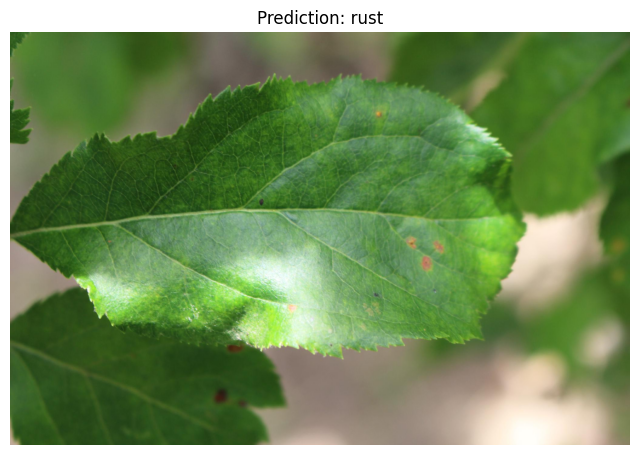

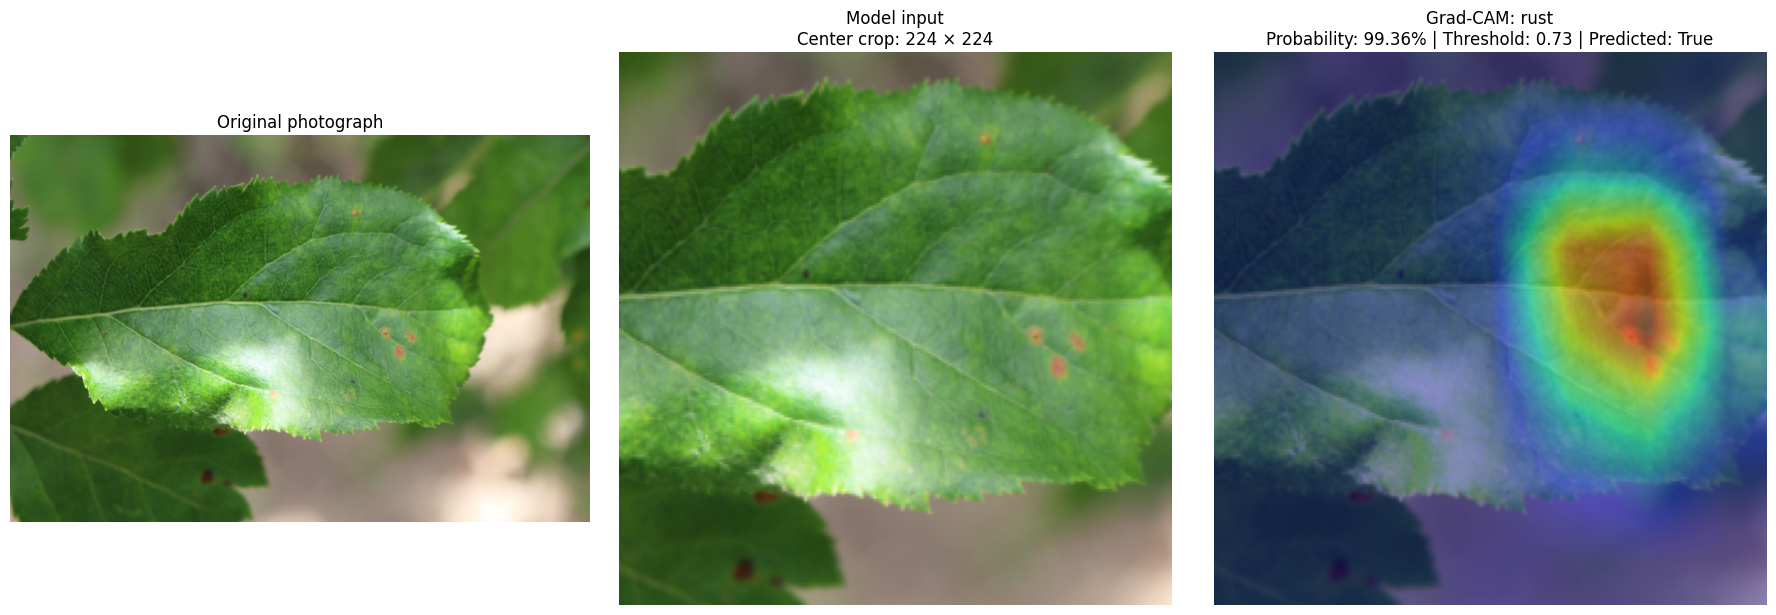


Image: E7GJyS31tBOb0Crrz7LapVSC3p2cbnZr8-kUiheO9aBY-vfg4d0FCRdXGVoRbUfEZ0ErRTfaUjcHb2nlIKJ2ydSJBrmx0ViQnBk7hcaUnkfgzKrZh9U-EQxQtVnHG6kgRd_bOERfPUqP-3E3JW94sCSq2KhOsCBTr4InntQs0FfzA3y1pztkUEkXc1rnRU9D (1).jpg
Prediction: rust, complex


,class,probability,threshold,predicted
0,rust,95.63%,0.73,True
1,complex,78.93%,0.77,True
2,scab,9.22%,0.72,False
3,frog_eye_leaf_spot,5.39%,0.57,False
4,powdery_mildew,3.35%,0.69,False
5,healthy,0.79%,0.43,False


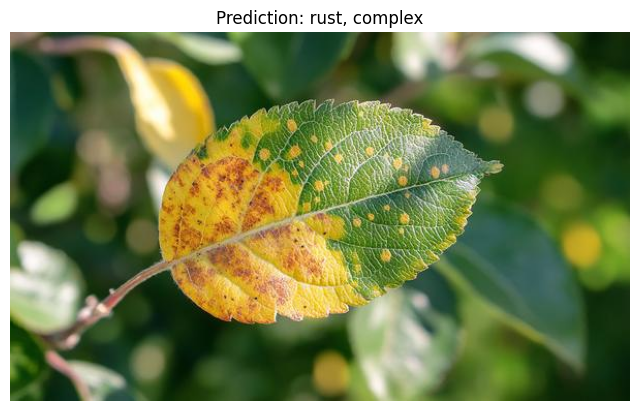

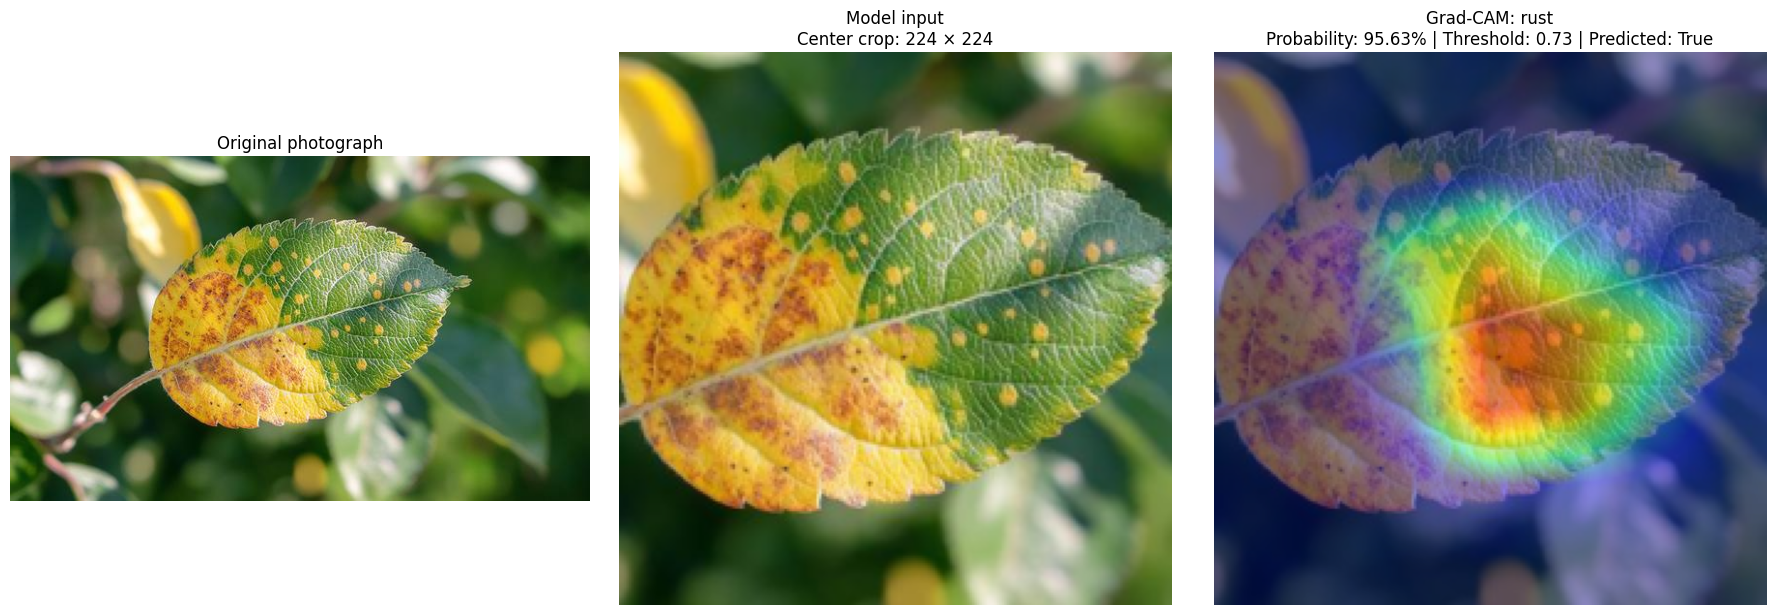

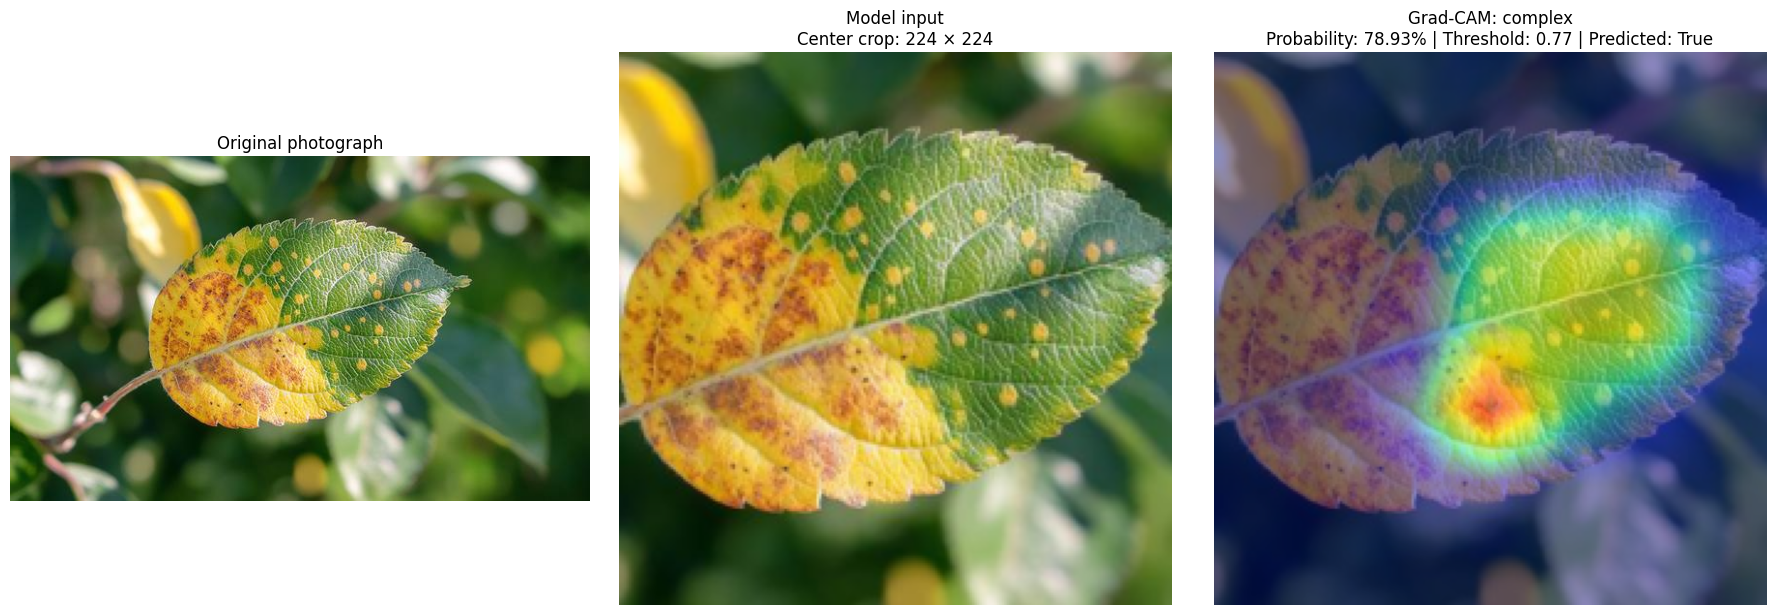


Image: used-1-IMG_20250502_152436421 (1).webp
Prediction: scab


,class,probability,threshold,predicted
0,scab,90.39%,0.72,True
1,frog_eye_leaf_spot,7.23%,0.57,False
2,rust,3.14%,0.73,False
3,complex,0.96%,0.77,False
4,healthy,0.93%,0.43,False
5,powdery_mildew,0.01%,0.69,False


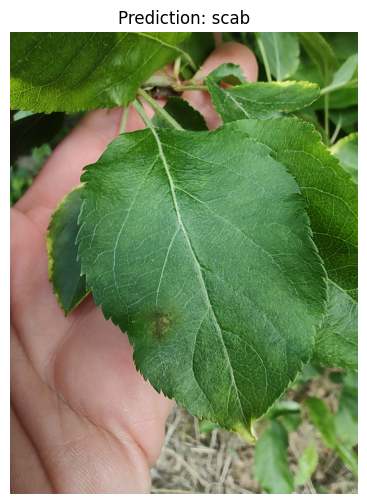

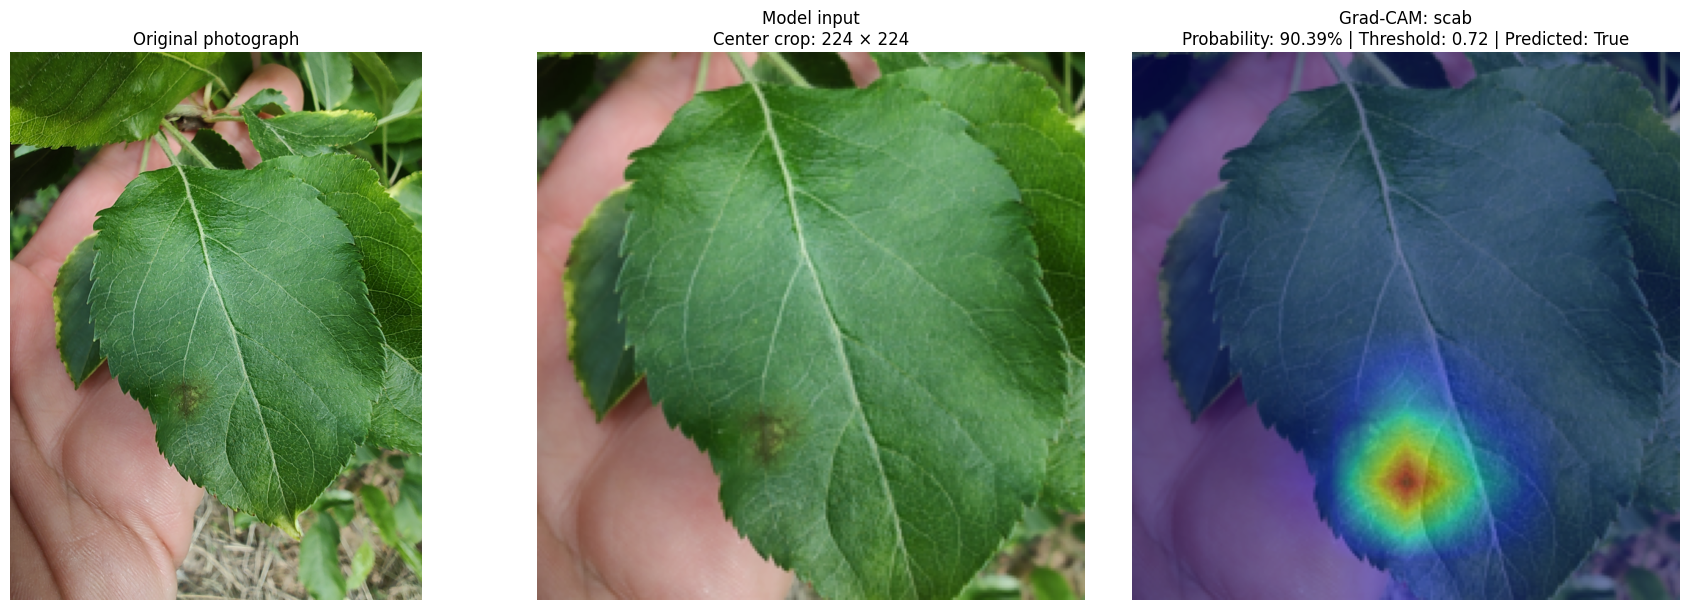

In [ ]:
print(
    "Upload one or more leaf photographs "
    "(.jpg, .jpeg, .png, .webp, or .bmp)."
)


uploaded_images = files.upload()


valid_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp",
    ".bmp",
}


SHOW_GRADCAM = True


all_predictions = {}
all_gradcams = {}


for filename in uploaded_images:
    file_path = Path(filename)


    if file_path.suffix.lower() not in valid_extensions:
        print(
            f"Skipped {filename}: "
            f"unsupported image format."
        )
        continue


    prediction = predict_leaf(filename)

    if prediction is None:
        continue


    all_predictions[filename] = prediction
    all_gradcams[filename] = {}

    if not SHOW_GRADCAM:
        continue
    results = prediction["probabilities"]
    predicted_classes = results.loc[
        results["predicted"],
        "class",
    ].tolist()
    disease_classes = [
        class_name
        for class_name in predicted_classes
        if class_name != "healthy"
    ]


    if disease_classes:
        classes_to_explain = disease_classes

    else:
        classes_to_explain = [
            results.iloc[0]["class"]
        ]


    for class_name in classes_to_explain:
        gradcam_result = show_gradcam(
            image_path=filename,
            class_name=class_name,
        )

        all_gradcams[filename][
            class_name
        ] = gradcam_result

## Predict more images

To test additional photographs during the same Colab session, rerun only Section 3. The model remains loaded in memory and Drive does not need to be mounted again.